1. Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# Nombres de columnas del dataset
columnas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Cargar train y test
df_train = pd.read_csv('data/adult.data', names=columnas, 
                        skipinitialspace=True)
df_test  = pd.read_csv('data/adult.test', names=columnas, 
                        skipinitialspace=True, skiprows=1)

print("✅ Dataset cargado correctamente")
print(f"Train - Filas: {df_train.shape[0]}, Columnas: {df_train.shape[1]}")
print(f"Test  - Filas: {df_test.shape[0]},  Columnas: {df_test.shape[1]}")

✅ Dataset cargado correctamente
Train - Filas: 32561, Columnas: 15
Test  - Filas: 16281,  Columnas: 15


2. Vista general

In [2]:
print("=== PRIMERAS FILAS ===")
display(df_train.head())

print("\n=== TIPOS DE VARIABLES ===")
print(df_train.dtypes)

=== PRIMERAS FILAS ===


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



=== TIPOS DE VARIABLES ===
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object


3. Limpiar valores faltantes marcados como '?'

In [3]:
# En este dataset los nulos vienen como '?'
df_train.replace('?', np.nan, inplace=True)
df_test.replace('?', np.nan, inplace=True)

nulos = df_train.isnull().sum()
porcentaje = (nulos / len(df_train) * 100).round(2)

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)

print("=== VALORES NULOS (reemplazados desde '?') ===")
print(missing[missing['Valores nulos'] > 0])

=== VALORES NULOS (reemplazados desde '?') ===
                Valores nulos  Porcentaje (%)
occupation               1843            5.66
workclass                1836            5.64
native_country            583            1.79


4. Imputar nulos con KNN

In [4]:
numericas   = df_train.select_dtypes(include='number').columns.tolist()
categoricas = df_train.select_dtypes(include='object').columns.tolist()

# KNN para numéricas
imputer = KNNImputer(n_neighbors=5)
df_num = pd.DataFrame(
    imputer.fit_transform(df_train[numericas]),
    columns=numericas
)

# Moda para categóricas
df_cat = df_train[categoricas].fillna(df_train[categoricas].mode().iloc[0])

df_limpio = pd.concat([df_num, df_cat], axis=1)

print(f"✅ Imputación completada")
print(f"Nulos restantes: {df_limpio.isnull().sum().sum()}")

✅ Imputación completada
Nulos restantes: 0


C:\Users\Natalia\AppData\Local\Temp\ipykernel_2308\461677993.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df_train.select_dtypes(include='object').columns.tolist()


5. Estadísticas descriptivas

In [5]:
df_limpio.describe().round(2)

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


6. Distribución de ingresos (variable objetivo)

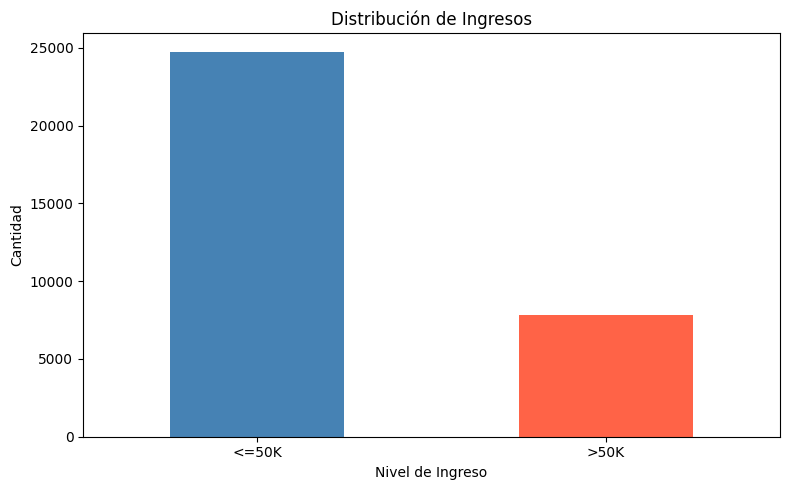

In [6]:
plt.figure(figsize=(8, 5))
df_limpio['income'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribución de Ingresos')
plt.xlabel('Nivel de Ingreso')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

7.  Ingreso por nivel educativo

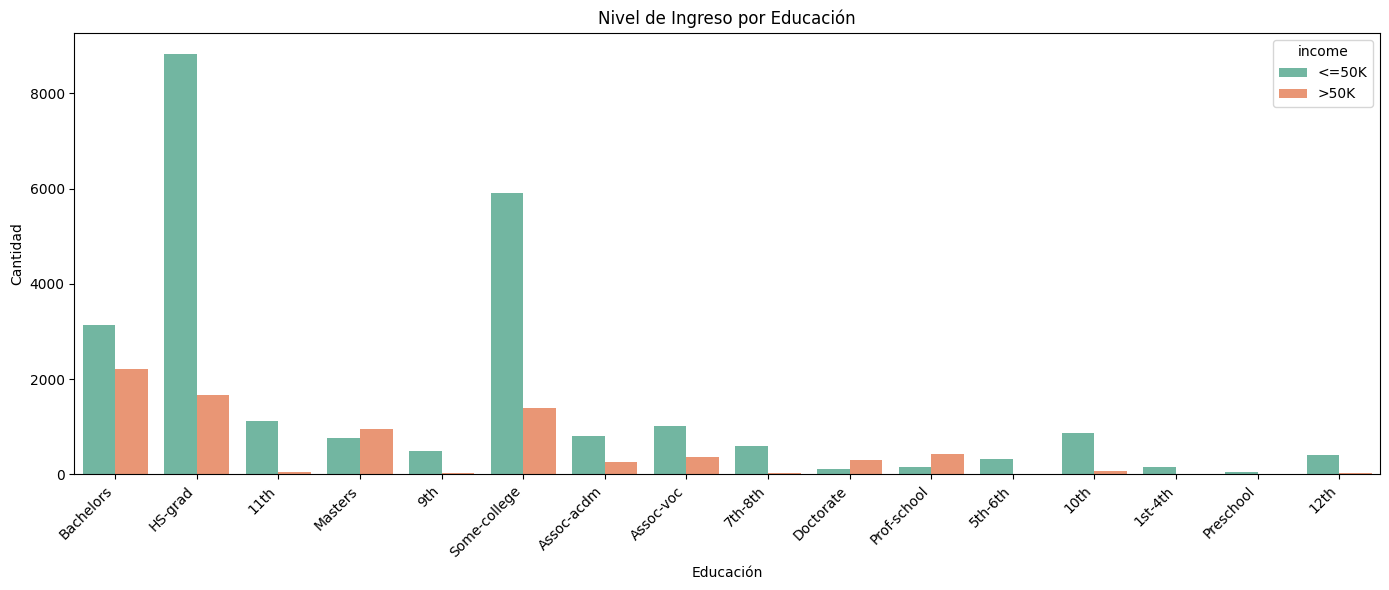

In [7]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df_limpio, x='education', hue='income', palette='Set2')
plt.title('Nivel de Ingreso por Educación')
plt.xlabel('Educación')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

8. Distribución de edad por nivel de ingreso

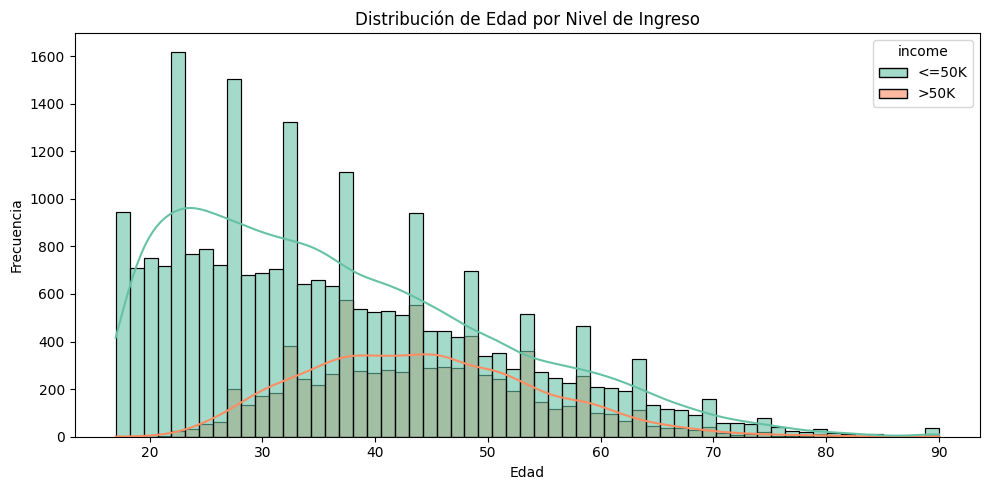

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_limpio, x='age', hue='income', 
             kde=True, palette='Set2', alpha=0.6)
plt.title('Distribución de Edad por Nivel de Ingreso')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

9. Correlaciones numéricas

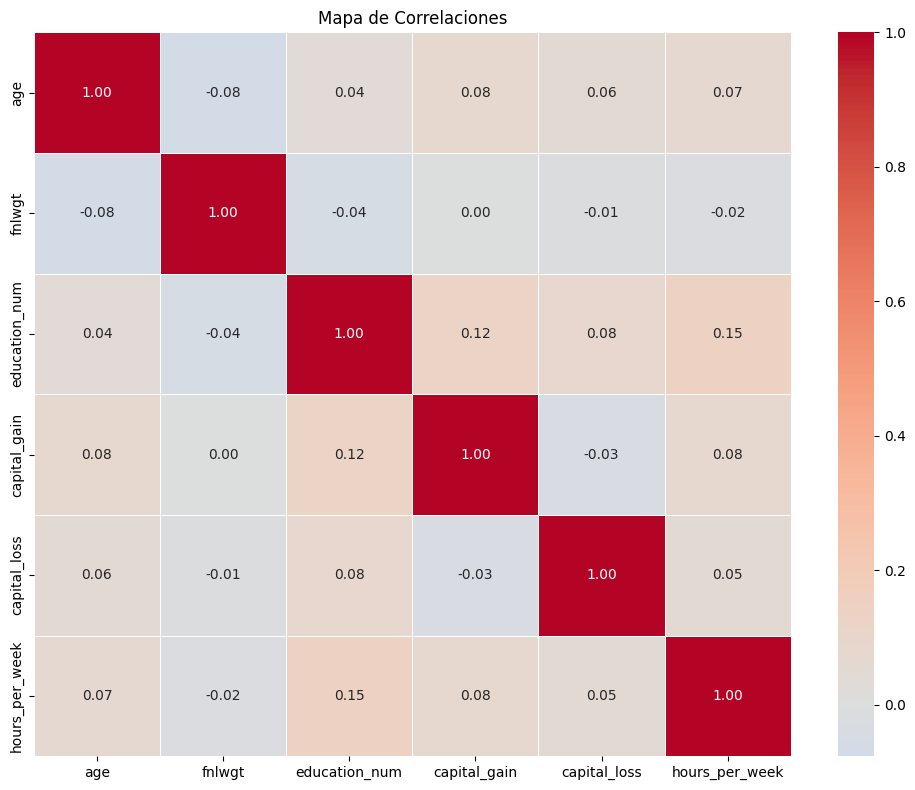

In [9]:
plt.figure(figsize=(10, 8))
corr = df_num.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, 
            linewidths=0.5, annot=True, fmt='.2f')
plt.title('Mapa de Correlaciones')
plt.tight_layout()
plt.show()